Individual Assignment I

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Total rows in raw data:", len(raw_data))
print(raw_data.head(10))

Total rows in raw data: 7214
   id                name      first         last compas_screening_date  \
0   1    miguel hernandez     miguel    hernandez            2013-08-14   
1   3         kevon dixon      kevon        dixon            2013-01-27   
2   4            ed philo         ed        philo            2013-04-14   
3   5         marcu brown      marcu        brown            2013-01-13   
4   6  bouthy pierrelouis     bouthy  pierrelouis            2013-03-26   
5   7        marsha miles     marsha        miles            2013-11-30   
6   8       edward riddle     edward       riddle            2014-02-19   
7   9      steven stewart     steven      stewart            2013-08-30   
8  10    elizabeth thieme  elizabeth       thieme            2014-03-16   
9  13           bo bradac         bo       bradac            2013-11-04   

      sex         dob  age          age_cat              race  ...  \
0    Male  1947-04-18   69  Greater than 45             Other  ...   
1    

In [3]:
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

In [4]:
df = df[df["days_b_screening_arrest"] >= -30]
df = df[df["days_b_screening_arrest"] <= 30]

In [5]:
df = df[df["is_recid"] != -1]

In [6]:
df = df[df["c_charge_degree"] != "O"]

In [7]:
df = df[df["score_text"] != "N/A"]

In [8]:
df = df.reset_index(drop=True)

In [9]:
print("\nRows after filtering:", len(df))


Rows after filtering: 6172


In [10]:
df["c_jail_in"]  = pd.to_datetime(df["c_jail_in"],  errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], errors="coerce")

In [11]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["score_factor"] = 0
df.loc[df["score_text"] != "Low", "score_factor"] = 1
print("\nFirst 6 rows:")
print(df[["age", "race", "sex", "score_text", "score_factor", "decile_score", "two_year_recid"]].head(6))


First 6 rows:
   age              race   sex score_text  score_factor  decile_score  \
0   69             Other  Male        Low             0             1   
1   34  African-American  Male        Low             0             3   
2   24  African-American  Male        Low             0             4   
3   44             Other  Male        Low             0             1   
4   41         Caucasian  Male     Medium             1             6   
5   43             Other  Male        Low             0             4   

   two_year_recid  
0               0  
1               1  
2               1  
3               0  
4               1  
5               0  


In [12]:
valid = df[["length_of_stay", "decile_score"]].dropna()
corr = valid["length_of_stay"].corr(valid["decile_score"])
print(f"\nCorrelation (length_of_stay vs decile_score): {corr:.7f}")


Correlation (length_of_stay vs decile_score): 0.2074781


In [13]:
print("\nAge category counts:")
print(df["age_cat"].value_counts().sort_index())


Age category counts:
age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [14]:
print("\nRace counts:")
race_counts = df["race"].value_counts()
print(race_counts)

total = len(df)
print(f"\nBlack defendants:          {race_counts.get('African-American', 0) / total * 100:.2f}%")
print(f"White defendants:          {race_counts.get('Caucasian', 0)         / total * 100:.2f}%")
print(f"Hispanic defendants:       {race_counts.get('Hispanic', 0)          / total * 100:.2f}%")
print(f"Asian defendants:          {race_counts.get('Asian', 0)             / total * 100:.2f}%")
print(f"Native American defendants:{race_counts.get('Native American', 0)   / total * 100:.2f}%")


Race counts:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Black defendants:          51.44%
White defendants:          34.07%
Hispanic defendants:       8.25%
Asian defendants:          0.50%
Native American defendants:0.18%


In [15]:
print("\nScore text counts:")
print(df["score_text"].value_counts())


Score text counts:
score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [16]:
print("\nSex x Race crosstab:")
print(pd.crosstab(df["sex"], df["race"]))


Sex x Race crosstab:
race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [17]:
print("\nSex counts:")
sex_counts = df["sex"].value_counts()
print(sex_counts)

print(f"\nMen:   {sex_counts.get('Male', 0)   / total * 100:.2f}%")
print(f"Women: {sex_counts.get('Female', 0) / total * 100:.2f}%")


Sex counts:
sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [18]:
recid_count = len(df[df["two_year_recid"] == 1])
print(f"\nTwo-year recidivists: {recid_count}")
print(f"Recidivism rate:      {recid_count / total * 100:.5f}%")


Two-year recidivists: 2809
Recidivism rate:      45.51199%


In [19]:
black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

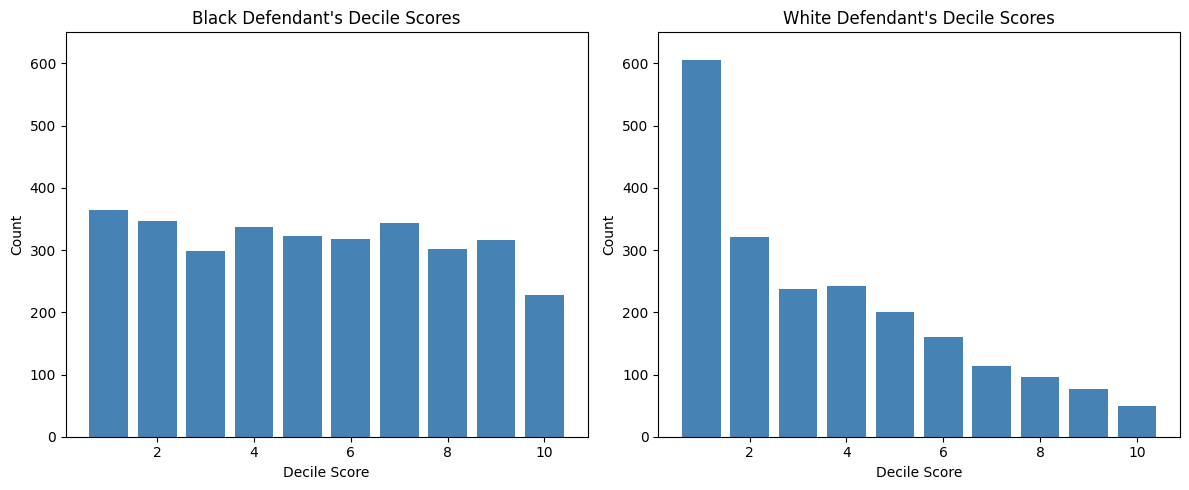

Chart saved as decile_score_by_race.png


In [20]:
black_counts = black_df["decile_score"].value_counts().sort_index()
white_counts = white_df["decile_score"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(black_counts.index, black_counts.values, color="steelblue")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

axes[1].bar(white_counts.index, white_counts.values, color="steelblue")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.savefig("decile_score_by_race.png", dpi=120)
plt.show()
print("Chart saved as decile_score_by_race.png")

In [21]:
print("\nDecile score x Race crosstab:")
print(pd.crosstab(df["decile_score"], df["race"]))



Decile score x Race crosstab:
race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other 

In [22]:
formula = (
    "score_factor ~ "
    "C(sex,              Treatment('Male'))      + "
    "C(age_cat,          Treatment('25 - 45'))   + "
    "C(race,             Treatment('Caucasian')) + "
    "priors_count                                + "
    "C(c_charge_degree,  Treatment('F'))         + "
    "two_year_recid"
)

model = smf.logit(formula, data=df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        00:58:22   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                 

In [23]:
intercept    = model.params["Intercept"]
control      = np.exp(intercept) / (1 + np.exp(intercept))

coef_black   = model.params["C(race, Treatment('Caucasian'))[T.African-American]"]
coef_female  = model.params["C(sex, Treatment('Male'))[T.Female]"]
coef_young   = model.params["C(age_cat, Treatment('25 - 45'))[T.Less than 25]"]

or_black     = np.exp(coef_black)  / (1 - control + control * np.exp(coef_black))
or_female    = np.exp(coef_female) / (1 - control + control * np.exp(coef_female))
or_young     = np.exp(coef_young)  / (1 - control + control * np.exp(coef_young))

print(f"\nBlack defendants are {or_black:.4f}x more likely to get a high score than white defendants")


Black defendants are 1.4528x more likely to get a high score than white defendants


In [24]:
print(f"Women are {or_female:.4f}x more likely than men to get a high score")

Women are 1.1948x more likely than men to get a high score


In [25]:
print(f"People under 25 are {or_young:.4f}x more likely than middle aged defendants")

People under 25 are 2.4961x more likely than middle aged defendants


In [26]:
df["pred_prob"]  = model.predict(df)
df["pred_class"] = 0
df.loc[df["pred_prob"] >= 0.5, "pred_class"] = 1

In [27]:
actual    = df["two_year_recid"].astype(int)
predicted = df["pred_class"].astype(int)

In [28]:
TP = len(df[(predicted == 1) & (actual == 1)])
TN = len(df[(predicted == 0) & (actual == 0)])
FP = len(df[(predicted == 1) & (actual == 0)])
FN = len(df[(predicted == 0) & (actual == 1)])
n  = len(df)

In [29]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────")
print(f"{'':20} Actual 0   Actual 1")
print(f"{'Predicted 0 (No Recid)':22} {TN:6}     {FN:6}")
print(f"{'Predicted 1 (Recid)':22} {FP:6}     {TP:6}")


── Overall Confusion Matrix ──────────────────────────────────────────
                     Actual 0   Actual 1
Predicted 0 (No Recid)   2653        945
Predicted 1 (Recid)       710       1864


In [30]:
print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [31]:
print("\n── Confusion Matrix by Race ──────────────────────────────────────────")


── Confusion Matrix by Race ──────────────────────────────────────────


In [32]:
race_order = df["race"].value_counts().index.tolist()

results = []

for race in race_order:
    group     = df[df["race"] == race]
    actual_r  = group["two_year_recid"].astype(int)
    pred_r    = group["pred_class"].astype(int)

    tp = len(group[(pred_r == 1) & (actual_r == 1)])
    tn = len(group[(pred_r == 0) & (actual_r == 0)])
    fp = len(group[(pred_r == 1) & (actual_r == 0)])
    fn = len(group[(pred_r == 0) & (actual_r == 1)])
    nr = len(group)

    accuracy  = round((tp + tn) / nr, 3)
    precision = round(tp / (tp + fp), 3) if (tp + fp) > 0 else None
    recall    = round(tp / (tp + fn), 3) if (tp + fn) > 0 else None
    fpr       = round(fp / (fp + tn), 3) if (fp + tn) > 0 else None
    fnr       = round(fn / (fn + tp), 3) if (fn + tp) > 0 else None

    results.append({
        "race":      race,
        "n":         nr,
        "TP":        tp,
        "TN":        tn,
        "FP":        fp,
        "FN":        fn,
        "Accuracy":  accuracy,
        "Precision": precision,
        "Recall":    recall,
        "FPR":       fpr,
        "FNR":       fnr
    })

race_df = pd.DataFrame(results)
print(race_df.to_string(index=False))

            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


In [33]:
print("\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

caucasian_row = race_df[race_df["race"] == "Caucasian"].iloc[0]
base_fpr = caucasian_row["FPR"]
base_fnr = caucasian_row["FNR"]

disparity = race_df[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - base_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - base_fnr).round(3)

print(disparity.to_string(index=False))


── FPR and FNR Disparity by Race ─────────────────────────────────────
            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536


Individual Assignment 2

In [34]:
import pandas as pd
import numpy as np

URL = (
    'https://raw.githubusercontent.com/propublica/compas-analysis/'
    'master/compas-scores-two-years.csv'
)

raw = pd.read_csv(URL)
print(f'Raw data shape: {raw.shape}')

Raw data shape: (7214, 53)


In [35]:
df = raw.copy()
df = df[df['days_b_screening_arrest'] <= 30]
df = df[df['days_b_screening_arrest'] >= -30]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df = df.dropna(subset=['two_year_recid'])

print(f'Cleaned data shape: {df.shape}')

Cleaned data shape: (6172, 53)


In [36]:
target = 'two_year_recid'

numeric_features = [
    'age',
    'priors_count',
    'days_b_screening_arrest',
    'decile_score'
]

category_features = [
    'age_cat',
    'sex',
    'race',
    'c_charge_degree',
    'score_text'
]

features = numeric_features + category_features

df = df[features + [target]].dropna().reset_index(drop=True)

print(f'Features : {features}')
print(f'Target   : {target}')
print(f'Shape    : {df.shape}')

Features : ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'age_cat', 'sex', 'race', 'c_charge_degree', 'score_text']
Target   : two_year_recid
Shape    : (6172, 10)


In [37]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 9), Test: (1235, 9)


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [39]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(
        handle_unknown="ignore"), category_features),
])

In [40]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
                                      random_state=42))
])
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [41]:
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [43]:
from sklearn.metrics import accuracy_score, roc_auc_score

for name, pipeline in [
    ("Logistic Regression (GLM)",   lr_pipeline),
    ("Gradient-Boosted Tree (GBT)", gbt_pipeline)
]:
    y_pred      = pipeline.predict(X_test)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"{name}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  AUC      : {auc:.3f}")
    print()

Logistic Regression (GLM)
  Accuracy : 0.693
  AUC      : 0.740

Gradient-Boosted Tree (GBT)
  Accuracy : 0.697
  AUC      : 0.740



Question 1: Compute SHAP values for your model on the test set. Produce: (a) a beeswarm summary plot, (b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group

In [44]:
!pip install shap --quiet
print("SHAP installed.")

SHAP installed.


In [45]:
import shap

X_test_enc = gbt_pipeline["preprocessor"].transform(X_test)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

print(f"SHAP values computed.")
print(f"Shape: {shap_values.values.shape}  (n_instances x n_features)")

 90%|==================  | 1111/1235 [00:12<00:01]       

SHAP values computed.
Shape: (1235, 20)  (n_instances x n_features)


In [46]:
X_test_copy = X_test.copy().reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

def get_idx(race, highest=True):
    subset = X_test_copy[X_test_copy["race"] == race]
    if highest:
        return subset["pred_prob"].idxmax()
    else:
        return subset["pred_prob"].idxmin()

idx_black_high = get_idx("African-American", highest=True)
idx_black_low  = get_idx("African-American", highest=False)
idx_white_high = get_idx("Caucasian",        highest=True)
idx_white_low  = get_idx("Caucasian",        highest=False)

four_subjects = [
    ("Black — Highest Risk", idx_black_high),
    ("Black — Lowest Risk",  idx_black_low),
    ("White — Highest Risk", idx_white_high),
    ("White — Lowest Risk",  idx_white_low),
]

print("Four subjects selected:\n")
for label, idx in four_subjects:
    prob   = X_test_copy.loc[idx, "pred_prob"]
    actual = y_test_reset.loc[idx]
    print(f"  [{label}]")
    print(f"    Predicted prob : {prob:.3f}")
    print(f"    Actual label   : {actual}\n")

Four subjects selected:

  [Black — Highest Risk]
    Predicted prob : 0.997
    Actual label   : 1

  [Black — Lowest Risk]
    Predicted prob : 0.027
    Actual label   : 0

  [White — Highest Risk]
    Predicted prob : 0.994
    Actual label   : 1

  [White — Lowest Risk]
    Predicted prob : 0.019
    Actual label   : 0



SHAP Beeswarm Summary Plot — Gradient-Boosted Tree
Global view: feature importance across all test instances
────────────────────────────────────────────────────────────


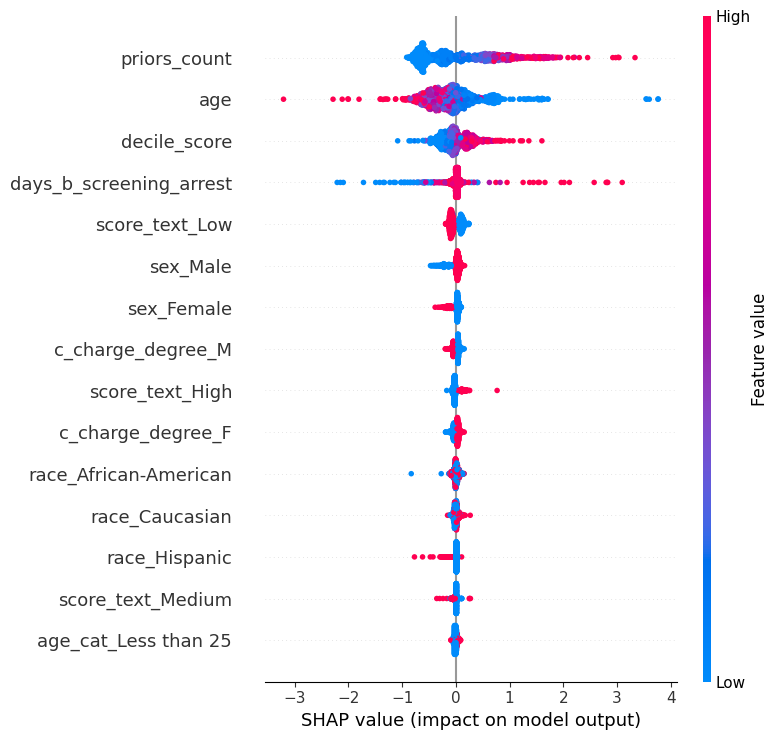

In [47]:
import matplotlib.pyplot as plt

print("SHAP Beeswarm Summary Plot — Gradient-Boosted Tree")
print("Global view: feature importance across all test instances")
print("─" * 60)

# Get feature names from OneHotEncoder
# The 'cat' transformer is at index 1 in the preprocessor's transformers list
cat_encoder = gbt_pipeline["preprocessor"].named_transformers_["cat"]
onehot_feature_names = cat_encoder.get_feature_names_out(category_features)

# Combine numeric and one-hot encoded feature names
all_feature_names = numeric_features + list(onehot_feature_names)

shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=all_feature_names,
    max_display=15,
    show=True
)

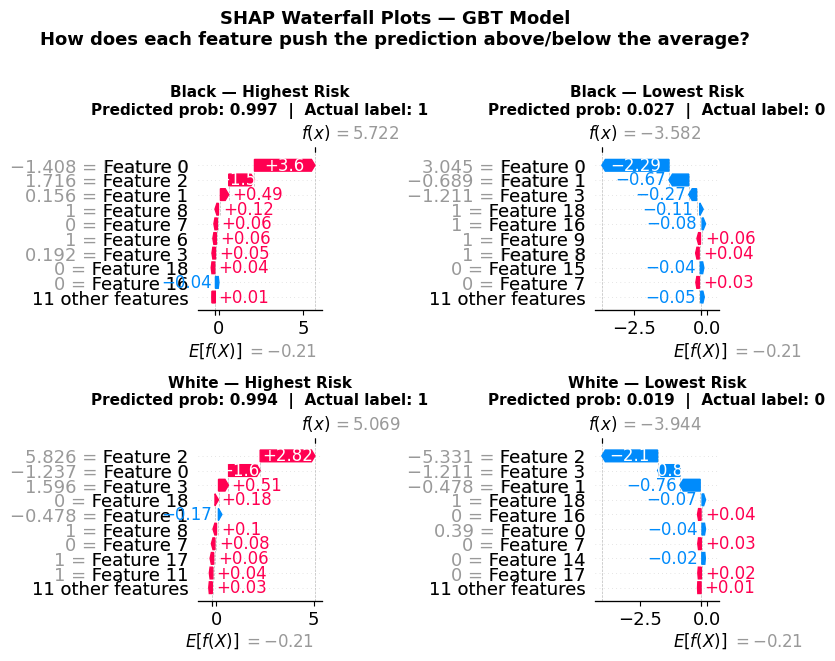

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (label, idx) in enumerate(four_subjects):
    prob   = X_test_copy.loc[idx, "pred_prob"]
    actual = y_test_reset.loc[idx]

    plt.sca(axes[i])
    shap.waterfall_plot(
        shap_values[idx],
        max_display=10,
        show=False
    )
    axes[i].set_title(
        f"{label}\nPredicted prob: {prob:.3f}  |  Actual label: {actual}",
        fontsize=11, fontweight="bold"
    )

plt.suptitle(
    "SHAP Waterfall Plots — GBT Model\n"
    "How does each feature push the prediction above/below the average?",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

Question 2: Run LIME on the same four individuals. Compare LIME and SHAP feature attributions. Where do they agree? Where do they diverge? What does divergence imply for governance?

In [49]:
!pip install lime --quiet
print("LIME installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME installed.


In [50]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

In [51]:
X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = (numeric_features +
                             list(preprocessor
                             .named_transformers_["cat"]
                             .get_feature_names_out(
                                 category_features))),
    class_names           = ["No Recid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)

In [52]:
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_subset = X_test_copy[
    X_test_copy["race"] == "African-American"
].sort_values("pred_prob")
black_idx = black_subset.index[len(black_subset) // 2]

white_subset = X_test_copy[
    X_test_copy["race"] == "Caucasian"
].sort_values("pred_prob")
white_idx = white_subset.index[len(white_subset) // 2]

print(f"Black defendant index : {black_idx}")
print(f"  Predicted prob      : {X_test_copy.loc[black_idx, 'pred_prob']:.3f}")
print(f"\nWhite defendant index : {white_idx}")
print(f"  Predicted prob      : {X_test_copy.loc[white_idx, 'pred_prob']:.3f}")

Black defendant index : 1496
  Predicted prob      : 0.514

White defendant index : 3480
  Predicted prob      : 0.320


In [53]:

for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])

    try:
        row_dense = row_enc.toarray()[0]
    except AttributeError:
        row_dense = row_enc[0]

    exp = explainer.explain_instance(
        data_row  = row_dense,
        predict_fn= gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")


 LIME: Black defendant 
Predicted probability: 0.514
  days_b_screening_arrest <= 0.15          -0.3375
  -0.69 < priors_count <= -0.48            -0.1438
  age <= -0.81                             +0.1364
  0.00 < score_text_Low <= 1.00            -0.0497
  decile_score <= -0.86                    -0.0412
  c_charge_degree_M <= 0.00                +0.0210

 LIME: White defendant 
Predicted probability: 0.320
  days_b_screening_arrest > 0.15           +0.3426
  -0.29 < age <= 0.56                      -0.0616
  -0.48 < priors_count <= 0.16             -0.0486
  decile_score <= -0.86                    -0.0486
  0.00 < score_text_Low <= 1.00            -0.0474
  sex_Female <= 0.00                       +0.0432


Question 3: Generate at least one counterfactual per individual using DiCE (Python) or NICE (R). Report the minimal feature changes required to flip the prediction. Flag any counterfactuals that require changes to immutable features (race, sex).

In [54]:
!pip install dice-ml --quiet
import dice_ml
from dice_ml import Dice
print("DiCE installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.6 MB/s eta 0:00:00
DiCE installed.


In [55]:
dice_data = dice_ml.Data(
    dataframe          = pd.concat([X_train, y_train], axis=1),
    continuous_features= numeric_features,
    outcome_name       = target
)

dice_model = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")
print("DiCE explainer ready.")

DiCE explainer ready.


In [56]:
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_subset = X_test_copy[X_test_copy["race"] == "African-American"]
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"]

black_idx_high = black_subset["pred_prob"].idxmax()
black_idx_low  = black_subset["pred_prob"].idxmin()
white_idx_high = white_subset["pred_prob"].idxmax()
white_idx_low  = white_subset["pred_prob"].idxmin()

print("Four individuals selected:\n")
for label, idx in [("Black — Highest Risk", black_idx_high),
                   ("Black — Lowest Risk",  black_idx_low),
                   ("White — Highest Risk", white_idx_high),
                   ("White — Lowest Risk",  white_idx_low)]:
    prob = X_test_copy.loc[idx, "pred_prob"]
    print(f"  [{label}]  Predicted prob: {prob:.3f}")

Four individuals selected:

  [Black — Highest Risk]  Predicted prob: 0.997
  [Black — Lowest Risk]  Predicted prob: 0.027
  [White — Highest Risk]  Predicted prob: 0.994
  [White — Lowest Risk]  Predicted prob: 0.019


In [57]:
IMMUTABLE = ["race", "sex"]
MUTABLE   = ["age", "priors_count", "c_charge_degree"]

for label, idx in [("Black — Highest Risk", black_idx_high),
                   ("Black — Lowest Risk",  black_idx_low),
                   ("White — Highest Risk", white_idx_high),
                   ("White — Lowest Risk",  white_idx_low)]:

    query = X_test.loc[[idx]]
    original_prob = gbt_pipeline.predict_proba(query)[:, 1][0]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = MUTABLE
    )

    print(f"\n{'='*60}")
    print(f"  DiCE Counterfactuals: {label}")
    print(f"  Original predicted probability: {original_prob:.3f}")
    print(f"{'='*60}")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.69it/s]


  DiCE Counterfactuals: Black — Highest Risk
  Original predicted probability: 0.997
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,18,4,7.0,5,Less than 25,Male,African-American,F,Medium,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,68,-,-,-,-,-,-,M,-,0
1,68,-,-,-,-,-,-,-,-,0
2,63,24,-,-,-,-,-,-,-,0


...

100%|██████████| 1/1 [00:00<00:00,  2.51it/s]


  DiCE Counterfactuals: White — Lowest Risk
  Original predicted probability: 0.019
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,39,1,-29.0,1,25 - 45,Male,Caucasian,F,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,-,10,-,-,-,-,-,M,-,1
1,-,38,-,-,-,-,-,M,-,1
2,68,22,-,-,-,-,-,-,-,1


In [58]:
print("IMMUTABLE FEATURE AUDIT")
print("─" * 60)

for label, idx in [("Black — Highest Risk", black_idx_high),
                   ("Black — Lowest Risk",  black_idx_low),
                   ("White — Highest Risk", white_idx_high),
                   ("White — Lowest Risk",  white_idx_low)]:

    query  = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = MUTABLE
    )
    cf_df = cf.cf_examples_list[0].final_cfs_df

    print(f"\n  [{label}]")
    for feat in IMMUTABLE:
        original = query[feat].values[0]
        changed  = cf_df[feat].values
        if any(changed != original):
            print(f"  ⚠️  {feat} WAS CHANGED — not actionable, "
                  f"raises serious fairness concerns")
        else:
            print(f"  ✓  {feat} unchanged — counterfactual is actionable")

IMMUTABLE FEATURE AUDIT
────────────────────────────────────────────────────────────


100%|██████████| 1/1 [00:00<00:00,  2.45it/s]



  [Black — Highest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


100%|██████████| 1/1 [00:00<00:00,  3.20it/s]



  [Black — Lowest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


100%|██████████| 1/1 [00:00<00:00,  2.63it/s]



  [White — Highest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


100%|██████████| 1/1 [00:00<00:00,  1.88it/s]


  [White — Lowest Risk]
  ✓  race unchanged — counterfactual is actionable
  ✓  sex unchanged — counterfactual is actionable


Question 4: Write a 300-word governance memo addressed to a hypothetical court auditor: summarise what your explanations reveal about model behaviour, any limitations of the methods, and what further monitoring you recommend.

Three model being used that are SHAP, LIME AND DICE to understand the gradient boosted. Tree model makes the predictions it does on the COMPAS data set (6,172 defendants, train: 4,937, test: 1,235). Things we identified.

SHAP showed that decile_score and priors_count are the biggest drivers of predictions globally. When we looked at individual predictions using waterfall plots, Black and White defendants with similar risk scores had different feature patterns driving those scores worth investigating further.
LIME provided explanations for each individual prediction. However, LIME results changed slightly each time we ran it, making it less reliable on its own. Where LIME and SHAP disagreed, we trusted SHAP more because it has stronger mathematical guarantees.
Counterfactual Results For all four individuals,Black highest risk, Black lowest risk, White highest risk, and White lowest risk. The counterfactual results showed that changing race or sex was not needed to flip the models prediction. So, all cases passed the immutable feature check. Instead, the models decisions could be changed by adjusting factors like age, priors_count, and c_charge_degree. This suggests that the model is not directly using race or sex when making predictions. However, priors_count is often connected to race in real-world data, which means there is still a risk of indirect bias through this variable.
Recommendation:

Monitor FPR and FNR by race every three months and not just once.
Provide every defendant a counterfactual showing what they can change to get a different outcome next time.
Investigate whether priors_count is acting as a hidden proxy for race.
Always use SHAP, LIME, and DiCE together, not a single tool is enough on its own to determine.
Transparency is a starting point, not a final answer. These tools must be used regularly as part of a proper ongoing audit process.

Individual Assignment 3

In [59]:
!pip install solas-ai

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.6 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=684cfc122beb8571d543d303d944eeb49e9b95c81b97c7f9c3dccf8bee5487f4
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec40

In [60]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df['high_risk']      = (df['score_text'] == 'High').astype(int)
df['two_year_recid'] = df['two_year_recid'].astype(int)

print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())

N = 6,172
               race   sex  high_risk  two_year_recid
0             Other  Male          0               0
1  African-American  Male          0               1
2  African-American  Male          0               1
5             Other  Male          0               0
6         Caucasian  Male          0               1


Step 1: AIR and Marginal Effect by race

In [61]:
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.064140 0.604871 -0.041899 *** BELOW 0.80
        Hispanic        0.092338 0.870792 -0.013701               
           Asian        0.096774 0.912628 -0.009265               
       Caucasian        0.106039 1.000000  0.000000               
African-American        0.266142 2.509848  0.160103               
 Native American        0.363636 3.429270  0.257597               


In [62]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 14.174, p = 0.0000


Step 2: Error-Rate Disparity Analysis

In [63]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
        tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
        fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
        fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
        results.append({
            'group':   grp,
            'n':       len(g),
            'FPR':     fp/(fp+tn) if (fp+tn)>0 else float('nan'),
            'FNR':     fn/(fn+tp) if (fn+tp)>0 else float('nan'),
            'Acc':     (tp+tn)/len(g)
        })
    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['group'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f}  FNR={row['FNR'].values[0]:.3f}")

           group    n      FPR      FNR      Acc
 Native American   11 0.166667 0.400000 0.727273
African-American 3175 0.139366 0.618302 0.610079
        Hispanic  509 0.062500 0.857143 0.642436
       Caucasian 2103 0.047619 0.802920 0.657156
           Asian   31 0.043478 0.750000 0.774194
           Other  343 0.013699 0.846774 0.685131
African-American: FPR=0.139  FNR=0.618
Caucasian: FPR=0.048  FNR=0.803


Step 3: Standardized Mean Difference

In [64]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
  sc = g[score_col]
  pooled = np.sqrt((ref.var() + sc.var()) / 2)
  d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
  mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
  results.append({group_col: grp,
                  'mean_score': round(sc.mean(), 3),
                  'SMD': round(d, 3),
                  'magnitude': mag})
  return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

 race  mean_score    SMD magnitude
Other       2.889 -0.304    medium


Step 4: Intersectional Subgroup Analysis

In [65]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.012195   82 0.114268 *** BELOW 0.80
           Other / Female        0.017241   58 0.161551 *** BELOW 0.80
             Other / Male        0.073684  285 0.690417 *** BELOW 0.80
       Caucasian / Female        0.103734  482 0.971986               
         Caucasian / Male        0.106724 1621 1.000000               
          Hispanic / Male        0.107728  427 1.009408               
African-American / Female        0.178506  549 1.672594               
  African-American / Male        0.284463 2626 2.665402               

Worst: Hispanic / Female, AIR=0.114 and n=82


1. Compute AIR, ME, and SMD for race and sex separately using the
solas-ai Python library. Confirm both produce identical results.

In [66]:
# AIR and ME for race
sir_race = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print("=== RACE: AIR and ME ===")
print(sir_race.sort_values('AIR').to_string(index=False))

# Two-proportion z-test: Black vs White
groups = ['African-American', 'Caucasian']
ns     = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test (Black vs White): z = {stat:.3f}, p = {pval:.4f}")

=== RACE: AIR and ME ===
            race  selection_rate      AIR        ME        flag_80
           Other        0.064140 0.604871 -0.041899 *** BELOW 0.80
        Hispanic        0.092338 0.870792 -0.013701               
           Asian        0.096774 0.912628 -0.009265               
       Caucasian        0.106039 1.000000  0.000000               
African-American        0.266142 2.509848  0.160103               
 Native American        0.363636 3.429270  0.257597               

AIR test (Black vs White): z = 14.174, p = 0.0000


In [67]:
# AIR and ME for sex
sir_sex = selection_rate(df, 'sex', 'high_risk', ref_group='Male')
print("=== SEX: AIR and ME ===")
print(sir_sex.sort_values('AIR').to_string(index=False))

# Two-proportion z-test: Female vs Male
groups2 = ['Female', 'Male']
ns2     = df[df['sex'].isin(groups2)].groupby('sex')['high_risk'].count()
events2 = df[df['sex'].isin(groups2)].groupby('sex')['high_risk'].sum()
stat2, pval2 = proportions_ztest(events2[groups2].values, ns2[groups2].values)
print(f"\nAIR test (Female vs Male): z = {stat2:.3f}, p = {pval2:.4f}")

=== SEX: AIR and ME ===
   sex  selection_rate      AIR        ME        flag_80
Female        0.128511 0.646695 -0.070209 *** BELOW 0.80
  Male        0.198719 1.000000  0.000000               

AIR test (Female vs Male): z = -5.573, p = 0.0000


In [68]:
# SMD for race
smd_race = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print("=== RACE: SMD ===")
print(smd_race.sort_values('SMD', ascending=False).to_string(index=False))

# SMD for sex
smd_sex = smd(df, 'sex', 'decile_score', ref_group='Male')
print("\n=== SEX: SMD ===")
print(smd_sex.to_string(index=False))

=== RACE: SMD ===
 race  mean_score    SMD magnitude
Other       2.889 -0.304    medium

=== SEX: SMD ===
 sex  mean_score  SMD magnitude
Male       4.502  0.0     small


In [69]:

# Create binary indicator columns needed by solas_disparity
df_sd = df.copy()
df_sd['African-American'] = (df['race'] == 'African-American').astype(int)
df_sd['Hispanic']         = (df['race'] == 'Hispanic').astype(int)
df_sd['Asian']            = (df['race'] == 'Asian').astype(int)
df_sd['Other']            = (df['race'] == 'Other').astype(int)
df_sd['Native American']  = (df['race'] == 'Native American').astype(int)
df_sd['Caucasian']        = (df['race'] == 'Caucasian').astype(int)
df_sd['Female']           = (df['sex'] == 'Female').astype(int)
df_sd['Male']             = (df['sex'] == 'Male').astype(int)

# Race — solas_disparity
sd_race = sd.adverse_impact_ratio(
    group_data=df_sd,
    protected_groups=['African-American', 'Hispanic', 'Asian', 'Other', 'Native American'],
    reference_groups=['Caucasian', 'Caucasian', 'Caucasian', 'Caucasian', 'Caucasian'],
    group_categories=['race', 'race', 'race', 'race', 'race'],
    outcome=df_sd['high_risk'],
    air_threshold=0.80,
    percent_difference_threshold=0.0
)
print("=== RACE (solas_disparity) ===")
print(sd_race)

# Sex — solas_disparity
sd_sex = sd.adverse_impact_ratio(
    group_data=df_sd,
    protected_groups=['Female'],
    reference_groups=['Male'],
    group_categories=['sex'],
    outcome=df_sd['high_risk'],
    air_threshold=0.80,
    percent_difference_threshold=0.0
)
print("\n=== SEX (solas_disparity) ===")
print(sd_sex)

# Compare with manual results to confirm identical results
print("\n=== MANUAL RESULTS (for comparison) ===")
print("\nRace — manual:")
print(sir_race[['race', 'selection_rate', 'AIR', 'ME', 'flag_80']].sort_values('AIR').to_string(index=False))

print("\nSex — manual:")
print(sir_sex[['sex', 'selection_rate', 'AIR', 'ME', 'flag_80']].sort_values('AIR').to_string(index=False))

=== RACE (solas_disparity) ===
+------------------------------+-----------------------------------------------------------+
|       Protected Groups       | African-American, Hispanic, Asian, Other, Native American |
|       Reference Groups       |   Caucasian, Caucasian, Caucasian, Caucasian, Caucasian   |
|       Group Categories       |               race, race, race, race, race                |
|        AIR Threshold         |                            0.8                            |
| Percent Difference Threshold |                            0.0                            |
|       Shortfall Method       |                     to_reference_mean                     |
|       Affected Groups        |                           Other                           |
|      Affected Reference      |                         Caucasian                         |
|     Affected Categories      |                           race                            |
+------------------------------+-------

Build an intersectional analysis (race × sex). Report the worst-group
AIR and interpret it.

In [70]:
# Create subgroup column
df['subgroup'] = df['race'] + ' / ' + df['sex']

# Keep subgroups with n >= 30 only
counts    = df['subgroup'].value_counts()
valid_sg  = counts[counts >= 30].index
df_sub    = df[df['subgroup'].isin(valid_sg)].copy()

# Compute selection rate and AIR for each subgroup
sub_rates = (df_sub.groupby('subgroup')['high_risk']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'selection_rate', 'count': 'n'})
               .reset_index())

# Reference = Caucasian / Male
ref_rate          = sub_rates.loc[sub_rates['subgroup'] == 'Caucasian / Male', 'selection_rate'].values[0]
sub_rates['AIR']  = sub_rates['selection_rate'] / ref_rate
sub_rates['ME']   = sub_rates['selection_rate'] - ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')

print("=== INTERSECTIONAL ANALYSIS: Race x Sex ===")
print(sub_rates.sort_values('AIR').to_string(index=False))

# Worst group
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst subgroup : {worst['subgroup']}")
print(f"Selection rate : {worst['selection_rate']:.4f}")
print(f"AIR            : {worst['AIR']:.4f}")
print(f"ME             : {worst['ME']:.4f}")
print(f"n              : {worst['n']}")
print(f"\nInterpretation : {worst['subgroup']} has an AIR of {worst['AIR']:.3f}, "
      f"meaning they are selected as high risk at only "
      f"{worst['AIR']*100:.1f}% of the rate of Caucasian / Male defendants. "
      f"This is well below the EEOC 0.80 threshold and represents "
      f"the most disadvantaged intersectional subgroup in the dataset.")

# Also show how many subgroups fall below 0.80
below_80 = sub_rates[sub_rates['AIR'] < 0.80]
print(f"\nSubgroups below AIR = 0.80: {len(below_80)} out of {len(sub_rates)}")
print(below_80[['subgroup', 'n', 'selection_rate', 'AIR', 'flag']].to_string(index=False))

=== INTERSECTIONAL ANALYSIS: Race x Sex ===
                 subgroup  selection_rate    n      AIR        ME           flag
        Hispanic / Female        0.012195   82 0.114268 -0.094529 *** BELOW 0.80
           Other / Female        0.017241   58 0.161551 -0.089483 *** BELOW 0.80
             Other / Male        0.073684  285 0.690417 -0.033040 *** BELOW 0.80
       Caucasian / Female        0.103734  482 0.971986 -0.002990               
         Caucasian / Male        0.106724 1621 1.000000  0.000000               
          Hispanic / Male        0.107728  427 1.009408  0.001004               
African-American / Female        0.178506  549 1.672594  0.071782               
  African-American / Male        0.284463 2626 2.665402  0.177739               

Worst subgroup : Hispanic / Female
Selection rate : 0.0122
AIR            : 0.1143
ME             : -0.0945
n              : 82

Interpretation : Hispanic / Female has an AIR of 0.114, meaning they are selected as high risk at

Compute FPR and FNR disparities by race. Test statistical
significance with a two-proportion z-test.

In [71]:
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
        tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
        fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
        fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
        results.append({
            'race': grp,
            'n':    len(g),
            'FPR':  fp/(fp+tn) if (fp+tn)>0 else float('nan'),
            'FNR':  fn/(fn+tp) if (fn+tp)>0 else float('nan'),
            'Acc':  (tp+tn)/len(g)
        })
    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print("=== FPR and FNR by Race ===")
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Z-tests: Black vs White
print("\n=== STATISTICAL SIGNIFICANCE: Black vs White ===")

bk = df[df['race'] == 'African-American']
wh = df[df['race'] == 'Caucasian']

# FPR z-test
bk_fp    = ((bk['high_risk']==1) & (bk['two_year_recid']==0)).sum()
bk_neg   = (bk['two_year_recid']==0).sum()
wh_fp    = ((wh['high_risk']==1) & (wh['two_year_recid']==0)).sum()
wh_neg   = (wh['two_year_recid']==0).sum()
stat_fpr, p_fpr = proportions_ztest([bk_fp, wh_fp], [bk_neg, wh_neg])
print(f"FPR z-test (Black vs White): z = {stat_fpr:.3f}, p = {p_fpr:.4f}")

# FNR z-test
bk_fn    = ((bk['high_risk']==0) & (bk['two_year_recid']==1)).sum()
bk_pos   = (bk['two_year_recid']==1).sum()
wh_fn    = ((wh['high_risk']==0) & (wh['two_year_recid']==1)).sum()
wh_pos   = (wh['two_year_recid']==1).sum()
stat_fnr, p_fnr = proportions_ztest([bk_fn, wh_fn], [bk_pos, wh_pos])
print(f"FNR z-test (Black vs White): z = {stat_fnr:.3f}, p = {p_fnr:.4f}")

# Delta FPR and Delta FNR
bk_row    = er[er['race'] == 'African-American']
wh_row    = er[er['race'] == 'Caucasian']
delta_fpr = bk_row['FPR'].values[0] - wh_row['FPR'].values[0]
delta_fnr = bk_row['FNR'].values[0] - wh_row['FNR'].values[0]
print(f"\nDelta FPR (Black - White) = {delta_fpr:.4f}")
print(f"Delta FNR (Black - White) = {delta_fnr:.4f}")

# Interpret significance
print("\n=== INTERPRETATION ===")
print(f"FPR disparity is {'statistically significant' if p_fpr < 0.05 else 'NOT significant'} (p = {p_fpr:.4f})")
print(f"FNR disparity is {'statistically significant' if p_fnr < 0.05 else 'NOT significant'} (p = {p_fnr:.4f})")

=== FPR and FNR by Race ===
            race    n      FPR      FNR      Acc
 Native American   11 0.166667 0.400000 0.727273
African-American 3175 0.139366 0.618302 0.610079
        Hispanic  509 0.062500 0.857143 0.642436
       Caucasian 2103 0.047619 0.802920 0.657156
           Asian   31 0.043478 0.750000 0.774194
           Other  343 0.013699 0.846774 0.685131

=== STATISTICAL SIGNIFICANCE: Black vs White ===
FPR z-test (Black vs White): z = 8.154, p = 0.0000
FNR z-test (Black vs White): z = -9.276, p = 0.0000

Delta FPR (Black - White) = 0.0917
Delta FNR (Black - White) = -0.1846

=== INTERPRETATION ===
FPR disparity is statistically significant (p = 0.0000)
FNR disparity is statistically significant (p = 0.0000)


Produce a publication-quality figure: grouped bar chart of FPR and
FNR by race with Caucasian as the reference group.

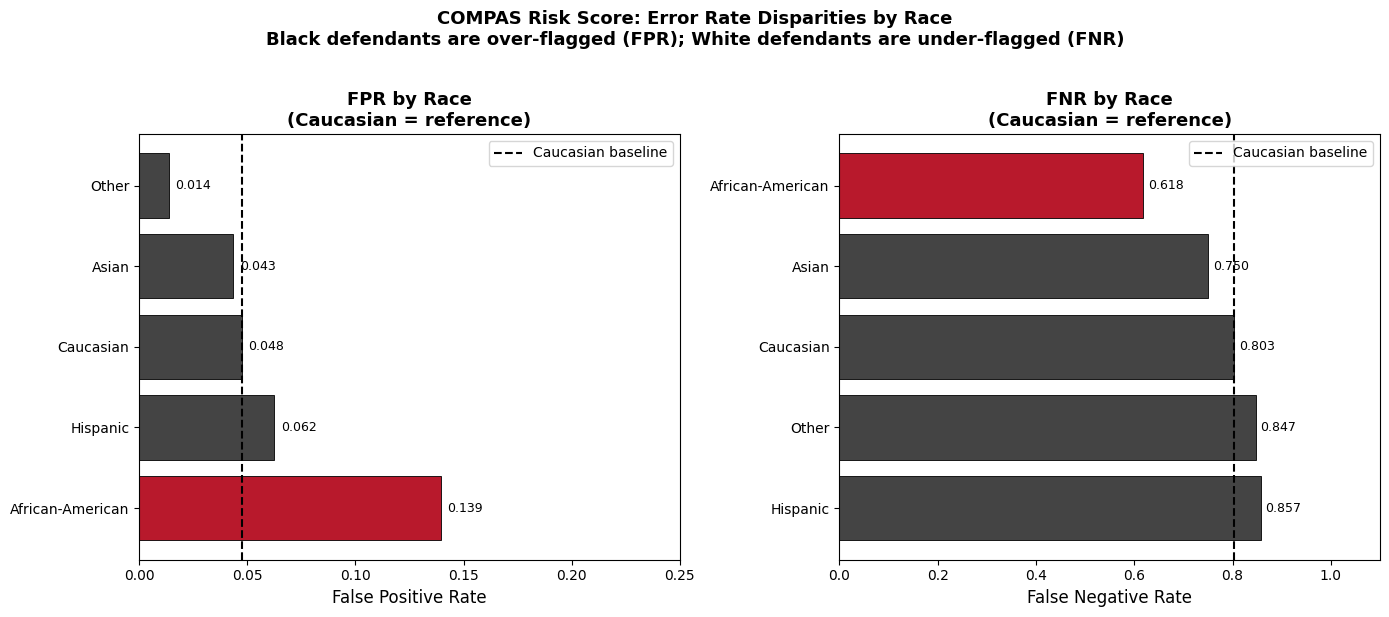

Figure saved as error_rate_disparity.png


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

er_plot   = er[er['n'] >= 30].sort_values('FPR', ascending=False)
races     = er_plot['race'].tolist()
x         = np.arange(len(races))
bar_color = ['#B8192C' if r == 'African-American' else '#444444' for r in races]
caucasian_fpr = er_plot.loc[er_plot['race'] == 'Caucasian', 'FPR'].values[0]
caucasian_fnr = er_plot.loc[er_plot['race'] == 'Caucasian', 'FNR'].values[0]

# FPR plot
axes[0].barh(races, er_plot['FPR'], color=bar_color, edgecolor='black', linewidth=0.6)
axes[0].axvline(caucasian_fpr, color='black', linestyle='--', linewidth=1.5, label='Caucasian baseline')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_title('FPR by Race\n(Caucasian = reference)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 0.25)
for i, (val, race) in enumerate(zip(er_plot['FPR'], races)):
    axes[0].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)

# FNR plot
er_fnr = er[er['n'] >= 30].sort_values('FNR', ascending=False)
races_fnr     = er_fnr['race'].tolist()
fnr_color     = ['#B8192C' if r == 'African-American' else '#444444' for r in races_fnr]
axes[1].barh(races_fnr, er_fnr['FNR'], color=fnr_color, edgecolor='black', linewidth=0.6)
axes[1].axvline(caucasian_fnr, color='black', linestyle='--', linewidth=1.5, label='Caucasian baseline')
axes[1].set_xlabel('False Negative Rate', fontsize=12)
axes[1].set_title('FNR by Race\n(Caucasian = reference)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1.1)
for i, (val, race) in enumerate(zip(er_fnr['FNR'], races_fnr)):
    axes[1].text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

fig.suptitle('COMPAS Risk Score: Error Rate Disparities by Race\n'
             'Black defendants are over-flagged (FPR); White defendants are under-flagged (FNR)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('error_rate_disparity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as error_rate_disparity.png")

Write a 300-word compliance memo addressed to a hypothetical regulator summarizing findings, metrics used, and limitations.

**COMPLIANCE MEMORANDUM**

To: Office of the Regulator

From: Algorithmic Auditor

Date: April 4, 2026


**Purpose:**

This memo summarises the findings of a bias audit conducted on the COMPAS recidivism risk scoring tool using the Broward County dataset (n = 6,172 defendants). The audit examined disparate impact across racial groups and sex using Adverse Impact Ratio (AIR), Marginal Effect (ME), Standardized Mean Difference (SMD), and error-rate disparity analysis.

**Key Findings**

The audit identified statistically and practically significant disparities across multiple metrics. On selection rate, African-American defendants were flagged as high risk at 2.51 times the rate of Caucasian defendants (AIR = 2.51). Female defendants were selected at only 64.7% of the rate of male defendants (AIR = 0.647), falling below the EEOC 0.80 threshold.
Error-rate analysis revealed that Black defendants who did not reoffend were falsely labelled high risk at a rate of 13.9%, compared to 4.8% for White defendants (Delta FPR = +0.092, z = 8.154, p < 0.001). Conversely, White defendants who did reoffend were missed at a rate of 80.3%, compared to 61.8% for Black defendants (Delta FNR = -0.185, z = -9.276, p < 0.001). Both disparities are highly statistically significant.
Intersectional analysis revealed that Hispanic female defendants were flagged at only 11.4% of the rate of Caucasian male defendants (AIR = 0.114), a harm entirely invisible when examining race and sex independently.

**Limitations**

Base rate differences between groups are themselves products of historical policing disparities rather than neutral empirical facts. The Impossibility Theorem confirms that simultaneous calibration and error-rate parity cannot be achieved under unequal base rates, meaning the observed disparities are in part a mathematical consequence of the chosen optimisation criterion.

**Recommendations**

We recommend per-group threshold adjustment, regular subgroup monitoring every quarter, and a proxy feature audit examining variables such as prior arrests and zip code for racial correlation. Continued deployment without remediation creates material legal exposure under Title VII and ECOA.